# Unsupervised Learning: Clustering Patient Testimonials

This notebook performs unsupervised learning on a dataset of patient testimonials.

## 1. Dataset Loading and Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

data = []
with open('Student_Dataset.csv', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue

        import csv
        parts = list(csv.reader([line]))[0]
        
        if len(parts) == 2:
            data.append({'ID': parts[0], 'Color': '0x000000', 'Testimony': parts[1]})
        elif len(parts) >= 3:
            data.append({'ID': parts[0], 'Color': parts[1], 'Testimony': parts[2]})

df = pd.DataFrame(data)
print(f"Loaded {len(df)} records.")
df.head()

Loaded 1011 records.


,ID,Color,Testimony
0,﻿1,0x000000,On uneven paths the heel feels wobbly side‑to‑...
1,2,0x000000,"The feverish feeling eased, but I’m now breath..."
2,3,0x000000,"While working in the garden, I touched a metal..."
3,4,0x000000,A short sprint brought on a twinge in the midd...
4,5,0x000000,I accidentally left my hand on a hot mug for a...


## 2. Data Pre-processing
We clean the testimonials

In [2]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_testimony'] = df['Testimony'].apply(clean_text)

tfidf = TfidfVectorizer(
    stop_words='english', 
    max_features=1000, 
    ngram_range=(1, 2)
)
X = tfidf.fit_transform(df['cleaned_testimony'])
print(f"TF-IDF Matrix shape: {X.shape}")

TF-IDF Matrix shape: (1011, 1000)


## 3. Training and Evaluation: Choosing k

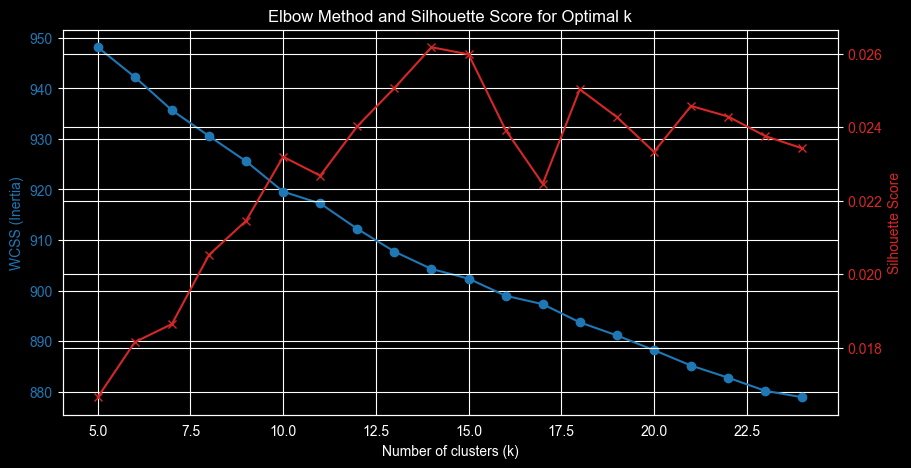

In [3]:
wcss = []
sil_scores = []
k_range = range(5, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(k_range, wcss, marker='o', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, sil_scores, marker='x', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method and Silhouette Score for Optimal k')
plt.show()

## 4. Final Clustering Model

In [4]:
optimal_k = 12
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

## 5. Cluster Insights

To understand what each cluster represents, we look at the most prominent words in each cluster's.

In [5]:
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()

print("Top terms per cluster:")
for i in range(optimal_k):
    print(f"Cluster {i}: ", end='')
    for ind in order_centroids[i, :8]:
        print(f'{terms[ind]}, ', end='')
    print()

Top terms per cluster:
Cluster 0: feel, skin, pale, notice, stand, dizzy, headaches, skin looks, 
Cluster 1: pressure, blood pressure, blood, chest, pressure chest, feeling, feel, constant, 
Cluster 2: cough, chest, short, breath, im, breathing, feel, night, 
Cluster 3: hot, red, skin, blister, touched, small, small blister, feels, 
Cluster 4: shoulder, reaching, sore, gives, makes, pull, deep, sharp, 
Cluster 5: itchy, rash, new, spots, raised, hives, welts, bumps, 
Cluster 6: pain, head, starts, feel, throbbing, throbbing pain, vision, pain starts, 
Cluster 7: knee, makes, long, leg, ache, thigh, standing, deep, 
Cluster 8: nose, throat, felt, mild, runny, cough, cold, day, 
Cluster 9: wrist, elbow, brings, feels, forearm, palm, ache, tender, 
Cluster 10: doctor, ive, vision, feel, thirsty, blood, weight, losing, 
Cluster 11: ear, pain, fever, hear, left ear, pain ear, cold, right ear, 


## 6. Visualization

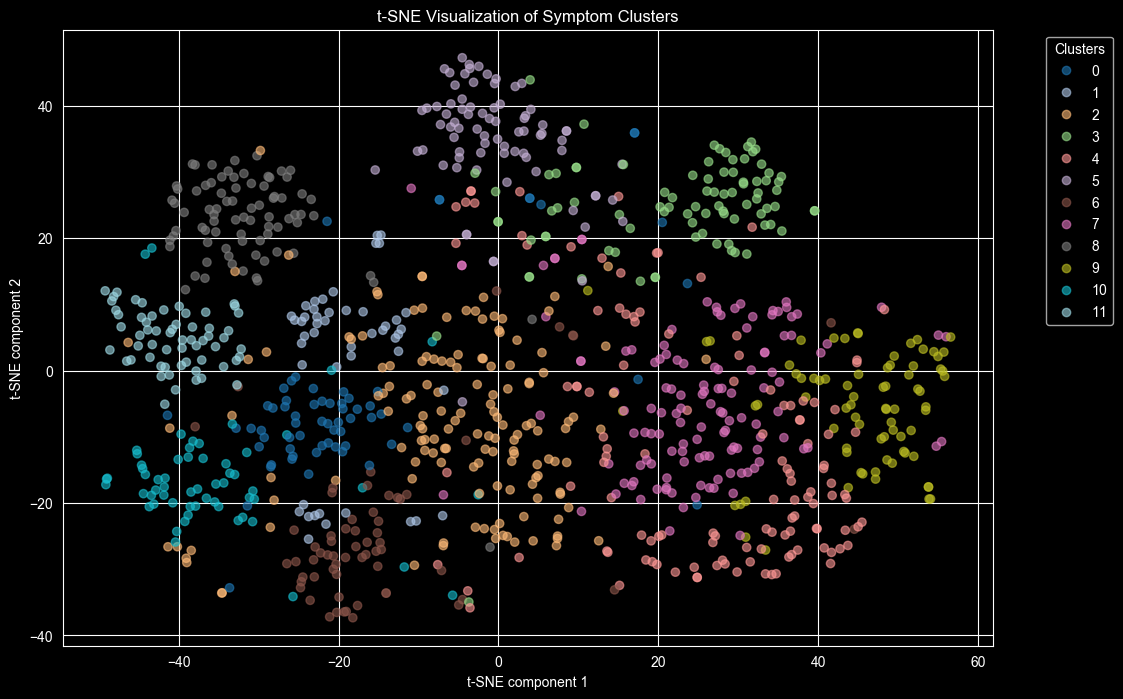

In [6]:
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X.toarray())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=df['cluster'], cmap='tab20', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE Visualization of Symptom Clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

## 7. Conclusions and Insights

The unsupervised learning model successfully grouped patient testimonials into coherent categories. Based on the top terms, we can identify several distinct pathologies:
- **Respiratory issues**: Cough, breathing, breath, chest tightness.
- **Dermatological**: Rash, itchy, hives, skin.
- **Orthopedic/Injury**: Ankle, knee, foot, pain, twisted.
- **Metabolic/Blood Sugar**: Thirsty, pee, weight, blood sugar.
- **Burns**: Blister, hot, red, burn, skin.
- **Headaches/Neurological**: Headache, head, pressure, temples.

These clusters align well with standard medical triage categories, demonstrating CVRIE's potential in sorting patient cases even without prior labeling.